---

<h1 style='color:#68C1EE'><b>Milestone 4</b></h1>


<h2 > <i> Baseline Model, Pipeline Development, and TF Meeting</i></h2>

<h3 ><b>Project Group #2: </b><i> Max Bahar, Mila Ivanovska, Stefan Chu, Ted McCulloch</i></h3>


---

In [1]:
# imports
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# utilities
import utils.preprocessing as pp
import utils.visualization as viz
import utils.time as tu

2025-04-26 23:42:25.042764: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-26 23:42:25.042806: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-26 23:42:25.043456: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-26 23:42:25.048540: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


#### Table of Contents [TODO/REQUIRED]

1. Introduction and Problem Statement

2. Comprehensive EDA

    i. Summary of Data

    ii. key findings 

    iii. other patterns? 

3. Baseline Model 

4. Baseline Model Results and Analysis

5. Final Model Setup 

[Milestone 4 Instructions](https://edstem.org/us/courses/74185/lessons/130679/slides/736237)
<div style='background: #FBB360; color: black'>
<h3><b>TODOs</b> [delete this cell prior to submission]</h3>

<b style='color:red'>

0. Elaine asked us to respond in the M3 comments about what we talked about with Pavlos 
</b>

1. Problem Statement Refinement and introduction:

- [DRAFTED] project introduction   

- [DRAFTED] refined problem statemnet 

- [DRAFTED but NEEDS WORK] Articulate significance based on new insights from EDA, highlighting shifts in perspective or understanding



2. **STEFAN:** Comprehensive EDA Review

- [] include key findings from your EDA paper, focusing on how these insights informed feature engineering and model selection.

- [] Detail the feature engineering process, including transformations, encoding, or selection techniques, with justifications rooted in EDA.

    - scaling, encoding, one hot encoding

    - if we are grouping by object we may want to vet for minimum number of states

    - anything else? 

- [] Include visualizations that support analytical decisions, linking back to the problem statement and project goals.



3. **MAX:** Baseline Model Selection and Justification

- [] Elaine suggested we use one from 209b; I think we should use one of the [Sequential Models](https://github.com/tedinspace/space-object-identification/blob/main/src/SequentialModels.ipynb) or [FFNN](https://github.com/tedinspace/space-object-identification/blob/main/src/FFNN.ipynb) that I have drafted. FFNN doesn't connect object states by number but sequential models do. 

- [] Explain the choice of your baseline model, considering simplicity, interpretability, and relevance.

    - if FFNN it considers all states as independent entities so that's a point for simplicity 

- [] Detail the training process, including preprocessing, parameters, and metrics used for evaluation.

- [] Present initial results, discussing alignment with expectations and project objectives.


4. **TED:** Results Interpretation and Analysis

- [] Analyze the baseline model’s performance, using appropriate metrics and visualizations.

- [] Assess strengths and weaknesses of the model, proposing improvements for the next iteration.

5. **MILA:** Final Model Pipeline Setup:

- [] Outline steps for a pipeline for your final model, describing each component from data preprocessing to evaluation.

    - we need to meet to discuss this

- [] Document assumptions, parameter choices, and preliminary tuning considerations.


<h3><b>REMINDERS/Notes</b></h3>

- <b>they will take off points for warnings so we need to squash those</b>

- we need to cite use of chat GPT in MLA style (more info in M4 instructions)

- table of contents is required

- titles and captions for plots




</div>



## 1. Introduction and Problem Statement

### 1.1 Background

Currently, there are around 30,000 publicly cataloged objects in Earth's orbit. In reality, the number is likely much higher, as 1) not every piece of debris in orbit has a known position or identification number,  2) not every payload is publicly disclosed by the government of origin, and  3) different organizations report varying figures.

Traditionally, space objects are classified into three categories:

1. **Payloads**: Functional spacecraft or satellites launched into space to perform specific missions, such as communication, navigation, or research.

2. **Rocket Bodies**: Parts of launch vehicles (e.g., stages) that delivered payloads to orbit but remain in space as non-operational objects.

3. **Debris**: Non-functional fragments or objects in space, including pieces from collisions, explosions, or decommissioned satellites, that no longer serve any purpose.

While all objects are subject to the same orbital perturbations, the nature of each object type should produce identifiable patterns in their orbital elements. For example, active payloads will conduct station-keeping maneuvers to maintain their desired orbits. Geostationary satellites, for instance, have orbital periods of nearly exactly 1,440 minutes—matching Earth's rotation. However, if they stop performing station-keeping maneuvers, their orbits will begin to drift due to various perturbative forces (gravity, drag, radiation pressure, solar activity, etc.). Likewise, although both are essentially space junk, debris and rocket bodies should also exhibit distinct orbital behaviors due to differences in their average size, mass, and origin.


### 1.2 Research Question



**Given a history of orbital states, can we predict with confidence any given object's type?**

Initially, we aimed to use two years of orbital data, removing time-dependent elements and identifiers to train our model to perform type classification. However, we are now pivoting to leverage the time dimension, using not a stationary set of elements, but rather a time-separated element histories as input to our three-type classification model. This pivot allows us to utilize more complex modeleling classes and techniques. 

Our EDA has confirmed that there are differences in orbital elements amongst object types, which are most pronounced in inclination, eccentritiy, apogee, and argument of perigee. Moreover, by examing the correlations between our features, we identified several meaningful patterns (and noted the ones which were trivial/meaningless). 

## 2.  Comprehensive EDA Review

### 2.1 Data Summary

Our final data frame consists of data from:

1. Historical State information - collected from spacetrack on the 1st and 15th of each moth ranging from 03/15/2023 to 03/15/2025.

2. Satellite catalog (satcat) information - descriptive information about a satellite.

3. Calculated additional values - semi-major axis, apogee, perigee, and orbital regime need to be calculated using state information.

#### 2.1.1 Variables

The table below explains the response variable and predictors to be used in our modeling.

<table>
    <tr>
        <th>Feature</th> <th>Data Type</th> <th>Units</th> <th>Description</th>
    </tr>
    <tr>
        <td>TYPE (response)</td> <td>String/Enum</td> <td>-</td> <td>Type of object: payload, debris, rocket body</td>
    </tr>
    <tr>
        <td>INCL</td> <td>Float</td> <td>Degree</td> <td>Orbit inclination</td>
    </tr>
    <tr>
        <td>RAAN</td> <td>Float</td> <td>Degree</td> <td>Right Ascension of the Ascending Node - longitude of the point where the spacecraft crosses the equatorial plane</td>
    </tr>
    <tr>
        <td>ECC</td> <td>Float</td> <td>[0,1]</td> <td>Eccentricity - measure of how circular or elliptical an orbit is</td>
    </tr>
    <tr>
        <td>ARG_PER</td> <td>Float</td> <td>Degree</td> <td>Argument of perigee - rotation/orientation of orbit</td>
    </tr>
    <tr>
        <td>MEAN_MOTION</td> <td>Float</td> <td>Rev/Day</td> <td>Revolutions per day given orbit</td>
    </tr>
    <tr>
        <td>SMA_KM</td> <td>Float</td> <td>KM</td> <td>Semi-major axis - the distance from the center of an ellipse to the longer end of the ellipse</td>
    </tr>
    <tr>
        <td>APOGEE_KM</td> <td>Float</td> <td>KM</td> <td>Furthest orbit gets from Earth</td>
    </tr>
    <tr>
        <td>PERIGEE_KM</td> <td>Float</td> <td>KM</td> <td>Closest orbit gets from Earth</td>
    </tr>
    <tr>
        <td>MEAN_MOTION_1ST_DER</td> <td>Float</td> <td>Rev/Day<sup>2</sup></td> <td>Ballistic coefficient measure</td>
    </tr>
    <tr>
        <td>MEAN_MOTION_2ND_DER</td> <td>???</td> <td>???</td> <td>???</td>
    </tr>
    <tr>
        <td>B_STAR</td> <td>???</td> <td>???</td> <td>???</td>
    </tr>
</table>

### 2.2 Key Findings

From our EDA, we were able to draw three main conclusions about the data which informed our feature engineering and data manipulation:

1. Mean anomaly is highly correlated with the epoch time and therefore likely does not contain meaningful information. We have decided to exclude it from our set of predictors.

2. We identified three meaningful patterns in the correlation matrix: (a) circular orbits have higher inclinations than elliptical orbits, (b) lower Earth orbits are more likely to be more inclined than higher Earth orbits, (c) lower Earth orbits tend to be more circular (lower eccentricity), while higher Earth orbits tend to be more elliptical (higher eccentricity). 

3. When comparing semi-major axis, inclination, and eccentricity, we observe apparent differences in patterns across object types, even when holding orbital regime constant.

In [2]:
# Separate features into different categories
X_numerical = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 'PERIGEE_KM', 'MEAN_MOTION_1ST_DER'] 
X_numerical_revised = X_numerical + ['MEAN_MOTION_2ND_DER', 'B_STAR']
response = 'TYPE'

# Fetch final dataframe
df_final = pd.read_csv('../data/large/final_df_v1.csv') # <-- Run Part 1 of DataConsolidation.ipynb to produce file

In [3]:
# Separate data into separate dataframes for each class
df_payload = df_final[df_final['TYPE'] == 'PAYLOAD']
df_rb = df_final[df_final['TYPE'] == 'ROCKET BODY']
df_debris = df_final[df_final['TYPE'] == 'DEBRIS']  

#### 2.2.1 Correlation of Variables

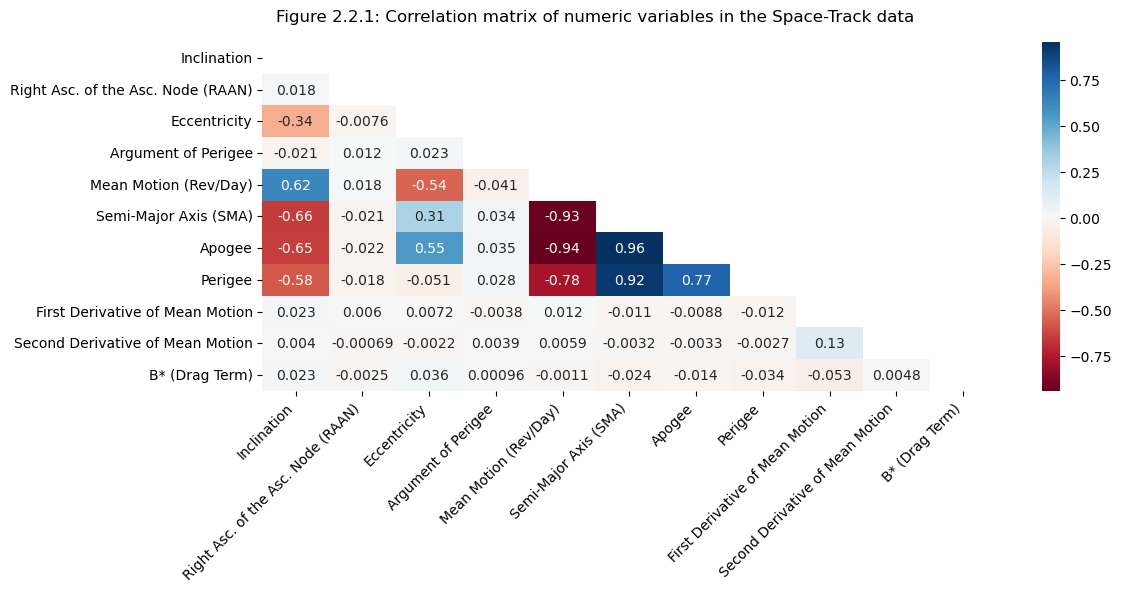

In [4]:
viz.plot_corr_matrix(df_final, X_numerical_revised, viz.pretty_column_names(), "Figure 2.2.1: Correlation matrix of numeric variables in the Space-Track data")

<table>
    <tbody>
        <tr>
            <th>Pattern A</th>
            <td>Circular orbits tend to have higher inclinations than elliptical orbits.</td>
        </tr>
        <tr>
            <th>Pattern B</th>
            <td>Lower Earth orbits are more likely to be more inclined than higher Earth orbits.</td>
        </tr>
        <tr>
            <th>Pattern C</th>
            <td>Lower Earth orbits tend to be more circular (lower eccentricity), while higher Earth orbits tend to be more elliptical (higher eccentricity).</td>
        </tr>
        <tr>
            <th>Trivial</th>
            <td>Trivial comparisons amount to saying "larger orbits will be larger" or "smaller orbits will be smaller."</td>
        </tr>
    </tbody>
</table>

<p>These patterns are consistent with our understanding of orbital dynamics, and they hold between object types.</p>

#### 2.2.2 Distribution of Variables

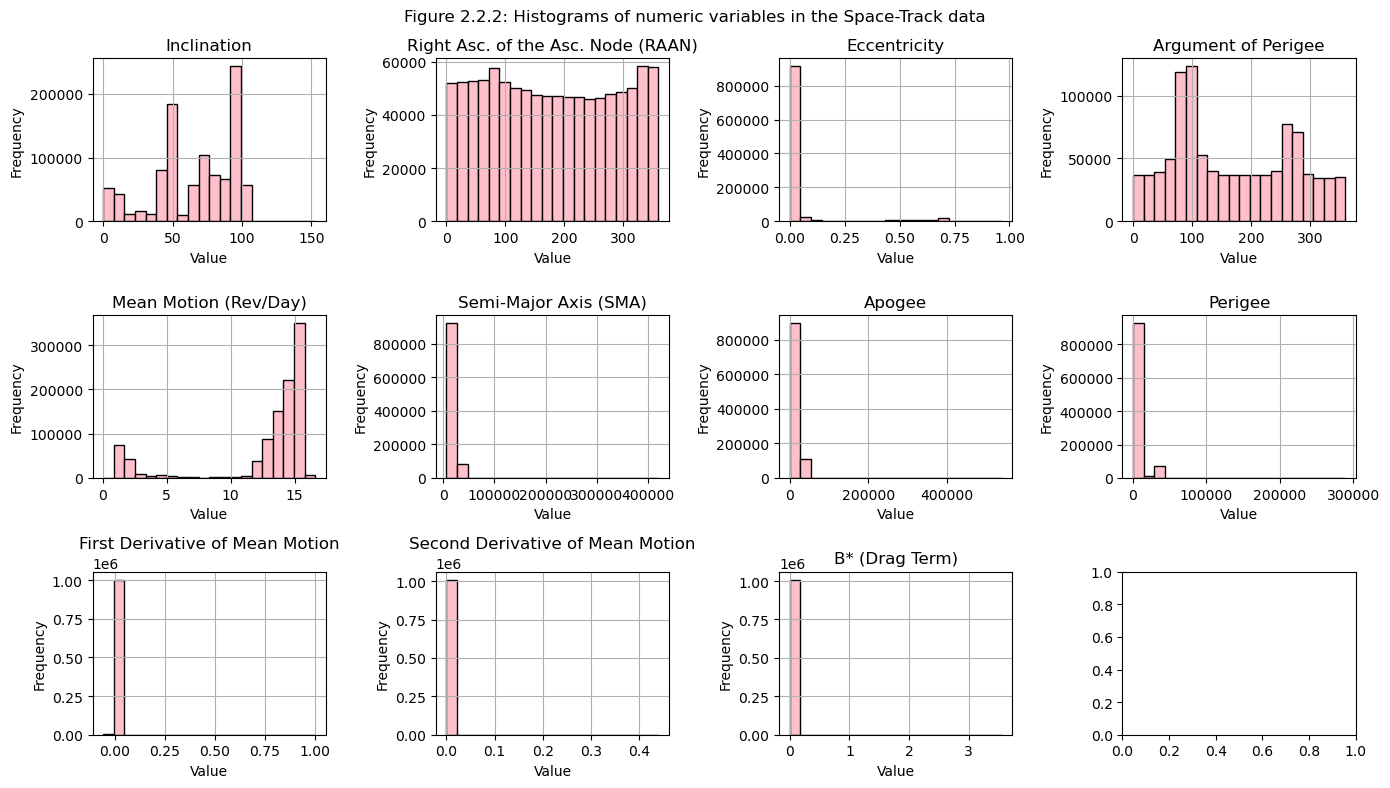

In [5]:
viz.plot_histograms(df_final, X_numerical_revised, viz.pretty_column_names(), "Figure 2.2.2: Histograms of numeric variables in the Space-Track data")

**MAX COMMENT: Add text on why figure 2.2.2 is important to show! Discuss why we scale our data this way?** 

**TED COMMENTs**

I think our EDA should include

- [DONE] correlation matrix with patterns table

    - [ADDED THE SUMMARIZED VERSION OF THE TABLE] I'm not sure if it's too detailed though 

- [DONE] one n x m stacked histogram (by type) plot with key orbital elements 

- [MOVED TO SECTION 5] plots summarizing how many states per object

    - some discussion of where we might cut this off and what this might do to our deta; this depends on what modeal we choose though 

- maybe PCA? 

- other plots supporting key findings? 

## 3. Baseline Model Selection and Justification

[] Explain the choice of your baseline model, considering simplicity, interpretability, and relevance.

[DONE] Detail the training process, including preprocessing, parameters, and metrics used for evaluation.

[] Present initial results, discussing alignment with expectations and project objectives.

### 3.1 Baseline Model Description

As our baseline model, we chose a Feedforward Neural Network (FNN) with the following architecture:
- 3 hidden dense layers with 500, 250, and 50 nodes and the ReLU activation function.
- A dropout layer after each of the dense layers with a dropout rate of 0.15.
- An output dense layer with 3 units (the number of classes in `TYPE`) with the softmax activation function.

We chose a FNN due to its relative simplicity in the context of 209B. We did our best to keep the model as simple as possible, choosing to omit any skip/residual connections, auxiliary blocks, or recurrent properties in the network architecture. The only form of regularization comes from the dropout layers in between each hidden dense layer. The model is relatively lightweight with a total of 142,953 trainable parameters and taking up 558.41 KB of memory.

We opted to neglect the time dimension of our data at this stage, simply passing in each state as a separate input to the model. In reality, multiple states may actually be from the same object at different points in time. We explore the time dependency of our modeling in the *"5. Final Model Pipeline Setup"* section further below.

**MAX COMMENT: Discuss interpretability and relevane?**

### 3.2 Training Process

We preprocessed our data by applying `StandardScaler` to each predictor, centering each predictor's mean at 0 with standard deviation of 1. This prevents 'exploding gradients' caused by large numerical values, particularly for semi-major axis, apogee, and perigree.

To tackle class imbalance, we trained the baseline model on the modified data upsampled with SMOTE, increasing the number of observations from 1,011,052 to 1,645,200.

We decided to use 76.5% of the data as the training set, 13.5% as the validation set, and the remaining 10% as the test set. We stratified on the type of the object associated with the state to ensure that each split was representative of the overall distribution.

**MAX COMMENT: Ask Elaine/Chris/TFs about using train/validation/test set here**

In [6]:
def preprocess_data(df_to_use, scaler, label_encoder, X_numerical, response, fit_scaler=True):

    X = df_to_use[X_numerical]
    y = df_to_use[response]
    y_encoded = label_encoder.fit_transform(y)
    if fit_scaler:
        scaler.fit(X)

    X_90, X_test, y_90, y_test = train_test_split(
        X, y_encoded,
        test_size=0.1,
        random_state=101,
        stratify=y_encoded
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_90, y_90,
        test_size=0.15,
        random_state=101,
        stratify=y_90
    )

    X_train = scaler.transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    
    return  X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler

For our baseline model training, we used the Adam optimizer with the default parameters of 0.001 learning rate, 0.9 exponential decay for the 1st momentum, and 0.999 exponential decay for the 2nd momentum.

The response variable is one-hot encoded, with the model minimizing categorical cross-entropy loss and tracking accuracy as an additional metric.

We chose to add early stopping with a patience of 5 (monitoring validation loss) in case of overfitting.

We also added a learning rate callback to reduce the learning rate by a factor of 0.5 (with a minimum learning rate of 1e-6) if validation loss does not improve after 3 epochs.

We chose a batch size of 32 to ensure the optimizer can get past local optima and trained for 25 epochs.

In [8]:
df_smote = pd.read_csv('../data/large/df_smote_v1.csv')  # <-- Run Part 2 of DataConsolidation.ipynb to produce file
label_encoder = LabelEncoder()
scaler = StandardScaler()
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler = preprocess_data(
    df_smote, scaler, label_encoder, X_numerical, response
)

# Baseline model parameters
DROPOUT = .15

model = models.Sequential()
model.add(layers.InputLayer(input_shape=(len(X_numerical),)))
model.add(layers.Dense(500, activation='relu'))  
model.add(layers.Dropout(DROPOUT))
model.add(layers.Dense(250, activation='relu'))  
model.add(layers.Dropout(DROPOUT))
model.add(layers.Dense(50, activation='relu'))  
model.add(layers.Dropout(DROPOUT))
model.add(layers.Dense(3, activation='softmax'))  

model.compile(optimizer=Adam(learning_rate=.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Only fit if saved weights aren't present
if os.path.exists("models/baseline_fnn.weights.h5"):
    model.load_weights("models/baseline_fnn.weights.h5")
    model.compile(optimizer=Adam(learning_rate=.001), loss='categorical_crossentropy', metrics=['accuracy'])
    with open("models/baseline_fnn_history.pkl", "rb") as file_pi:
        history = pickle.load(file_pi)
else:
    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        'models/baseline_fnn.weights.h5', 
        monitor='val_loss', 
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3, 
        verbose=1, 
        min_lr=1e-6
    )
    y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=3)
    y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes=3)
    history = model.fit(
        X_train, y_train_one_hot,
        validation_data=(X_val, y_val_one_hot),
        epochs=25,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr, checkpoint]
    )
    history = history.history
    with open("models/baseline_fnn_history.pkl", "wb") as file_pi:
        pickle.dump(history, file_pi)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 500)               5000      
                                                                 
 dropout_3 (Dropout)         (None, 500)               0         
                                                                 
 dense_5 (Dense)             (None, 250)               125250    
                                                                 
 dropout_4 (Dropout)         (None, 250)               0         
                                                                 
 dense_6 (Dense)             (None, 50)                12550     
                                                                 
 dropout_5 (Dropout)         (None, 50)                0         
                                                                 
 dense_7 (Dense)             (None, 3)                

### 3.3 Preliminary Results

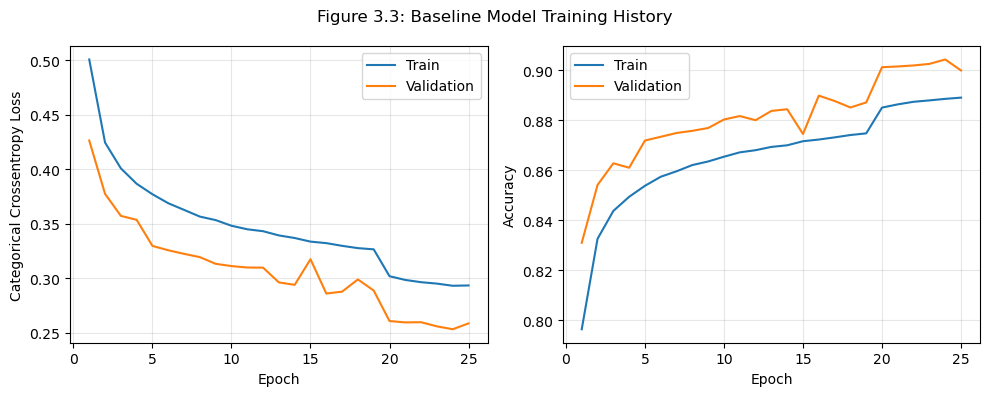

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,4))
ax1.plot(np.arange(len(history["loss"]))+1, history["loss"], label="Train")
ax1.plot(np.arange(len(history["val_loss"]))+1, history["val_loss"], label="Validation")
ax1.grid(alpha=0.3)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Categorical Crossentropy Loss")
ax1.legend()
ax2.plot(np.arange(len(history["accuracy"]))+1, history["accuracy"], label="Train")
ax2.plot(np.arange(len(history["val_accuracy"]))+1, history["val_accuracy"], label="Validation")
ax2.grid(alpha=0.3)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.suptitle("Figure 3.3: Baseline Model Training History")
plt.tight_layout()

In [10]:
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler = preprocess_data(
    df_final, scaler, label_encoder, X_numerical, response, fit_scaler=False,
)
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes=3)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes=3)

y_train_pred = np.argmax(model.predict(X_train), axis=-1)
train_loss, train_accuracy = model.evaluate(X_train, y_train_one_hot)
print(f"Train accuracy: {train_accuracy:.4f}")

y_val_pred = np.argmax(model.predict(X_val), axis=-1)
val_loss, val_accuracy = model.evaluate(X_val, y_val_one_hot)
print(f"Validation accuracy: {val_accuracy:.4f}")

y_test_pred = np.argmax(model.predict(X_test), axis=-1)
test_loss, test_accuracy = model.evaluate(X_test, y_test_one_hot)
print(f"Test accuracy: {test_accuracy:.4f}")


24171/24171 [==============================] - 28s 1ms/step - loss: 0.2749 - accuracy: 0.8790
Train accuracy: 0.8790
4266/4266 [==============================] - 5s 1ms/step - loss: 0.2739 - accuracy: 0.8798
Validation accuracy: 0.8798
3160/3160 [==============================] - 4s 1ms/step - loss: 0.2733 - accuracy: 0.8805
Test accuracy: 0.8805


## 4. Results Interpretation and Analysis

[] Analyze the baseline model’s performance, using appropriate metrics and visualizations.

[] Assess strengths and weaknesses of the model, proposing improvements for the next iteration.

### 4.1 Detailed Baseline Model Results

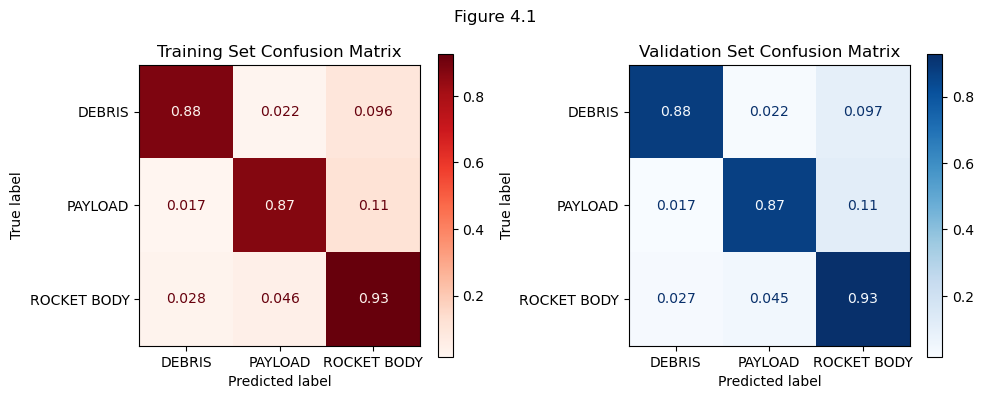

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
train_cm = confusion_matrix(y_train, y_train_pred, normalize="true")
train_cm_disp = ConfusionMatrixDisplay(train_cm, display_labels=label_encoder.classes_)
train_cm_disp.plot(cmap="Reds", ax=ax1)
ax1.set_title("Training Set Confusion Matrix")
val_cm = confusion_matrix(y_val, y_val_pred, normalize="true")
val_cm_disp = ConfusionMatrixDisplay(val_cm, display_labels=label_encoder.classes_)
val_cm_disp.plot(cmap="Blues", ax=ax2)
ax2.set_title("Validation Set Confusion Matrix")
plt.suptitle("Figure 4.1")
plt.tight_layout()

### 4.2 Pivot to Time-dependent Modeling

Since we are now interested in the time dimension of our data, it is important to examine how states are distributed across different objects in our dataset. If objects from a certain class have a more/less detailed state history, it could significantly impact the results of our model.

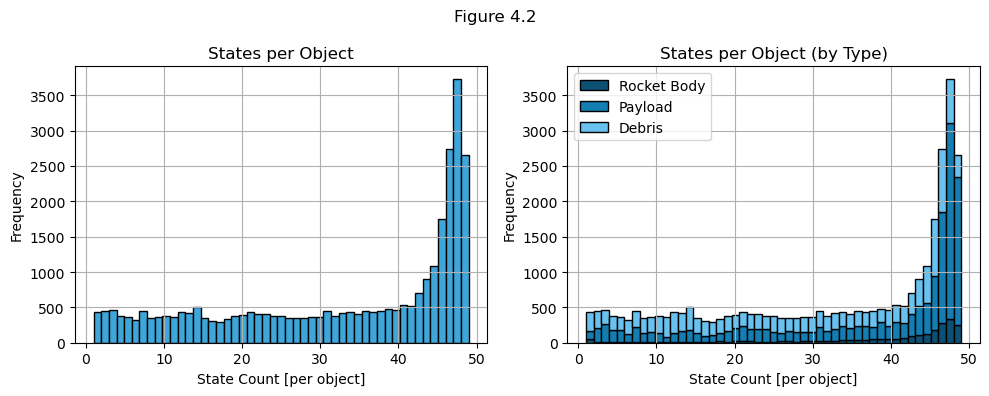

In [12]:
# Visualize number of states per object
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].hist(df_final['NUMBER'].value_counts().values, bins=49, edgecolor='black', color='#3FA6DA')
axs[0].set_title("States per Object")
axs[0].set_xlabel("State Count [per object]")
axs[0].set_ylabel("Frequency")
axs[0].grid(True)

axs[1].hist([df_rb['NUMBER'].value_counts().values,
             df_payload['NUMBER'].value_counts().values,
             df_debris['NUMBER'].value_counts().values], 
            bins=49, edgecolor='black', stacked=True, 
            color=["#0C5174", "#147EB3", "#68C1EE"], 
            label=['Rocket Body', 'Payload', 'Debris'])
axs[1].set_title("States per Object (by Type)")
axs[1].set_xlabel("State Count [per object]")
axs[1].set_ylabel("Frequency")
axs[1].legend()
axs[1].grid(True)

plt.suptitle("Figure 4.2")
plt.tight_layout()
plt.show()


Figure 2.1 plots the number of states per object. We can observe that most states have around 40-50 objects, with all three classes following this general distribution. **MAX COMMENT: Add more about rocket body's distribution maybe?**

In [13]:
# Group the states by the object, display time ranges for each object's states
df_epoch_min_max = df_final.groupby('NUMBER')['EPOCH'].agg(['min', 'max']).reset_index()
df_epoch_min_max['min_datetime'] = df_epoch_min_max['min'].apply(tu.year_doy_to_datetime)
df_epoch_min_max['max_datetime'] = df_epoch_min_max['max'].apply(tu.year_doy_to_datetime)

/tmp/ipykernel_2810/1628033826.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right");


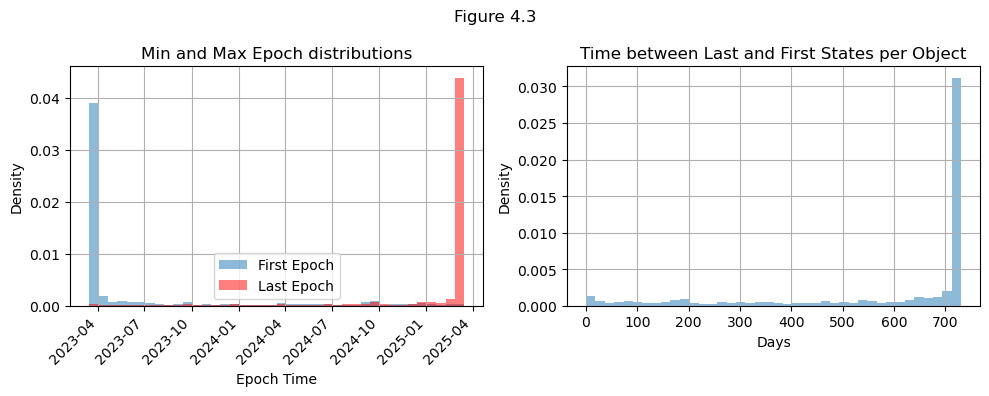

In [14]:
# Visualize distribution of earliest/latest state times and time ranges of states per object
num_bins = 40
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(df_epoch_min_max['min_datetime'], bins=num_bins, alpha=0.5, label='First Epoch', density=True)
ax1.hist(df_epoch_min_max['max_datetime'], bins=num_bins, alpha=0.5, label='Last Epoch', density=True, color='red')

ax1.set_xlabel('Epoch Time')
ax1.set_ylabel('Density')
ax1.set_title('Min and Max Epoch distributions')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right");
ax1.grid(True)
ax1.legend()

ax2.hist((df_epoch_min_max['max_datetime'] - df_epoch_min_max['min_datetime']).dt.days,
         bins=num_bins, alpha=0.5, density=True)

ax2.set_xlabel('Days')
ax2.set_ylabel('Density')
ax2.set_title('Time between Last and First States per Object')
ax2.grid(True)

plt.suptitle("Figure 4.3")
plt.tight_layout()
plt.show()


Figure 2.2 shows the distribution of the earliest and latest timestamp of the state histories of each object in our dataset. We can see that the first epoch for most of the objects in our dataset are on 2023-03-15, while most objects have a last epoch on 2025-03-15. This makes sense, since we collected our data by querying Space-Track's API every 15 days from 2023-03-15 to 2025-03-15. Consequently, most objects have a state history that span more than 700 days. We hope that this provides a sufficient amount of state information per object to make accurate class predictions for most objects. However, it is important to note that performance of the model can suffer for objects with shallow state histories.

## 5. Final Model Pipeline Setup

[] Outline steps for a pipeline for your final model, describing each component from data preprocessing to evaluation.

[] Document assumptions, parameter choices, and preliminary tuning considerations.


For our final model, we plan to use an ensemble machine learning technique such as blending, stacking, or mixture of experts to first train a neural network to make time-independent class predictions based purely off state information from one epoch. Then, we train a meta model to make a final class prediction based on the predictions of the previous model.

Graphically, for $x_t^{(i)}$, the state information in time $t$ for object $i$, and $y^{(i)}$, the class of object $i$:
$$
    x^{(i)}_t \rightarrow \text{MODEL 1} \rightarrow \{ p(y^{(i)}|x_1^{(i)}), \dots, p(y^{(i)}|x_t^{(i)}) \} \rightarrow \text{META MODEL} \rightarrow \hat{y}
$$

More concretely, we are hoping to build a neural network with the following architecture:
$$
    x_t^{(i)} \rightarrow \text{Neural Network 1 (with loss } \mathcal{L}_1 \text{)} \rightarrow \{ p(y|x_1^{(i)}), \dots, p(y|x_t^{(i)}) \} \rightarrow \text{Neural Network 2 (with loss } \mathcal{L}_2 \text{)} \rightarrow \hat{y}
$$
We hope to train the entire network simultaneously by combining the two loss functions $\mathcal{L}_1$ and $\mathcal{L}_2$. 

**MAX COMMENT: Maybe look at the distribution of classes in the objects that don't meet the minimum number of states.**

---

## Notes from Pavlos OH

Use **Mixture of Experts**! Use a meta model to aggregate the predictions from the first model and predict the class using a second model. 

We have $N$ states that consist of multiple states from $M$ objects.

We create a first model that predicts all $N$ states.

For each object, we choose $K$ observation/state predictions (will need to be padded/truncated for objects with less/more than $K$ observation/state predictions). 

Then, we create a second model that aggregates the $K$ observations for each of the $M$ objects to generate a class prediction for each object.

Graphically, for $x_t^{(i)}$, the state in time $t$ for observation $i$:
$$
    x^{(i)}_t \rightarrow \text{MODEL 1} \rightarrow \{ p(y|x_1^{(i)}), \dots, p(y|x_t^{(i)}) \} \rightarrow \text{META MODEL} \rightarrow \hat{y}
$$

We must be very careful about creating validation sets, making sure that these are defined correctly.

Pavlos mentioned that the meta model could be a RNN, specifying a max length for the specific fold/window of predictions/data to use by the meta model.

Meta model could also utilize gates to learn which specific inputs they should prioritize.

Keywords to look for: ,ixture models, stacking models, blending models.

If Pavlos were designing it, the architecture would look like:
$$
    x_t^{(i)} \rightarrow \text{NN}_1 \rightarrow \{ p(y|x_1^{(i)}), \dots, p(y|x_t^{(i)}) \} \rightarrow \text{NN}_2 \rightarrow \hat{y}
$$
And the loss from NN_1 and NN_2 are combined somehow to train the model simultaneously.

---

### Usage of ChatGPT [TODO - PROPER FORMATTING]

1. used it to help manipulate dataframe values relative to 'NUMBER' grouping
